In [117]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import k_means
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.preprocessing import (StandardScaler)
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [83]:
df=pd.read_csv("Mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [84]:
print("Shape of the dataframe is ",df.shape)
print("-"*64)
print("Column names are\n",df.columns)
print("Information of the dataset")
print("-"*64)
df.info()

Shape of the dataframe is  (200, 5)
----------------------------------------------------------------
Column names are
 Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')
Information of the dataset
----------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

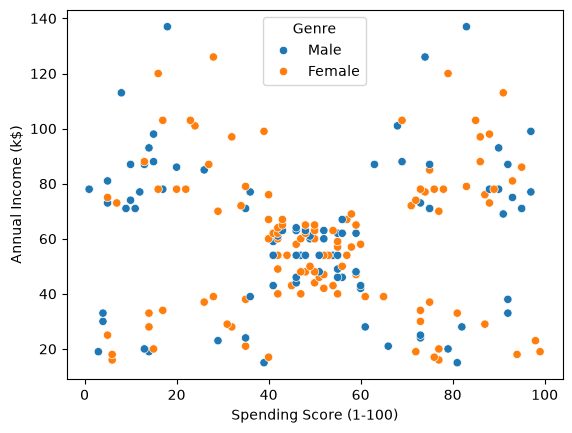

In [85]:
sns.scatterplot(x="Spending Score (1-100)",y="Annual Income (k$)",data=df,hue="Genre")

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

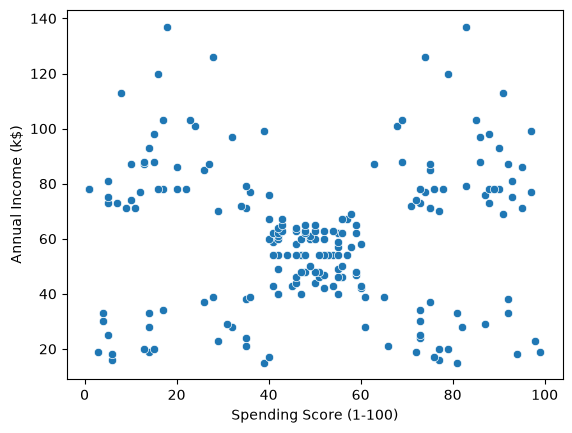

In [86]:
sns.scatterplot(x="Spending Score (1-100)",y="Annual Income (k$)",data=df)

<Axes: xlabel='Spending Score (1-100)', ylabel='Age'>

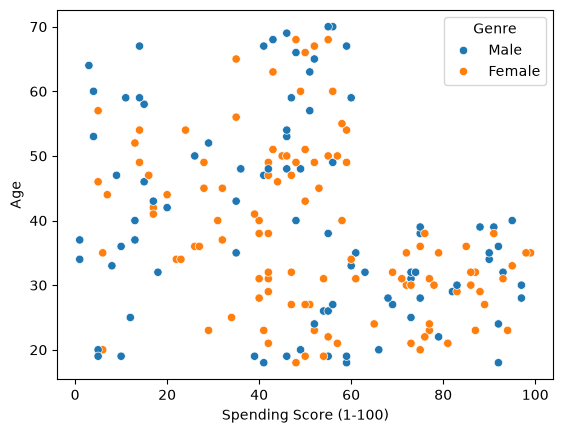

In [87]:
sns.scatterplot(x="Spending Score (1-100)",y="Age",data=df,hue="Genre")

<Axes: ylabel='Spending Score (1-100)'>

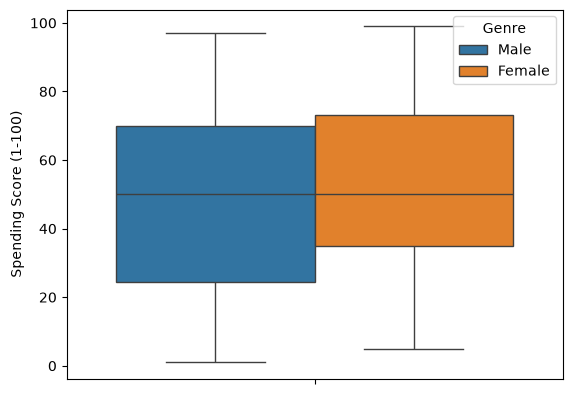

In [88]:
sns.boxplot(y="Spending Score (1-100)",hue="Genre",data=df)

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

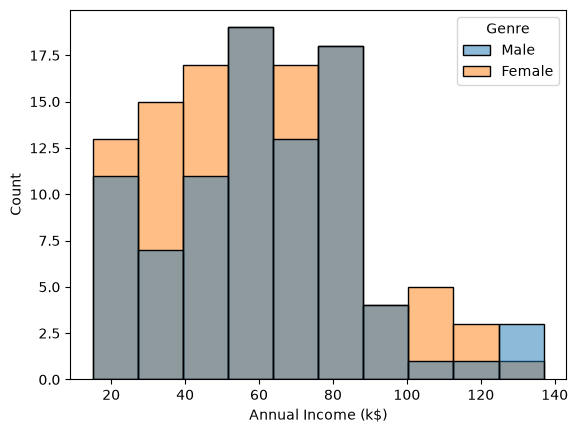

In [89]:
sns.histplot(x="Annual Income (k$)",hue="Genre",data=df)

<Axes: ylabel='Age'>

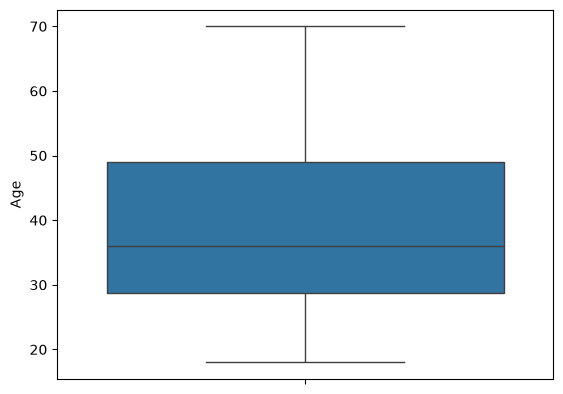

In [90]:
sns.boxplot(y="Age",data=df)

<Axes: xlabel='Age', ylabel='Count'>

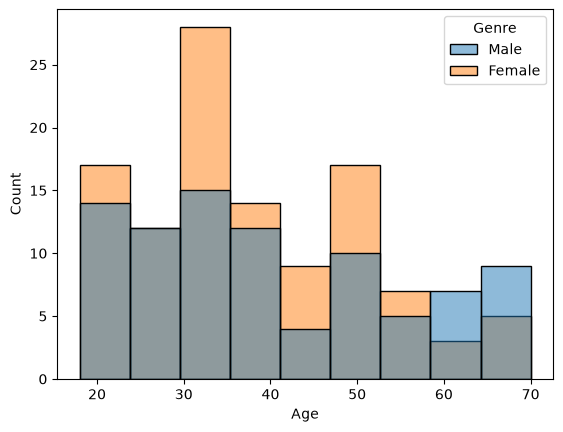

In [91]:
sns.histplot(x="Age",hue="Genre",data=df)

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

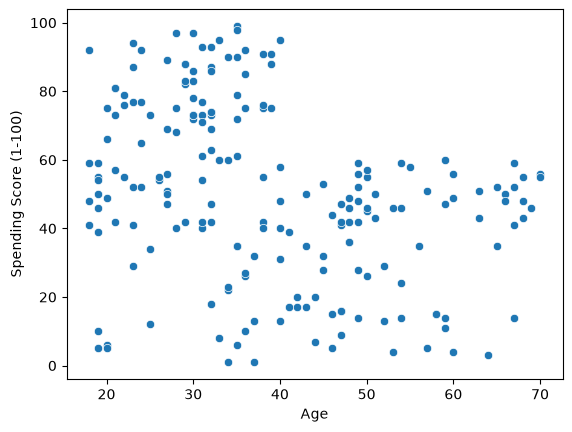

In [92]:
sns.scatterplot(x="Age",y="Spending Score (1-100)",data=df)

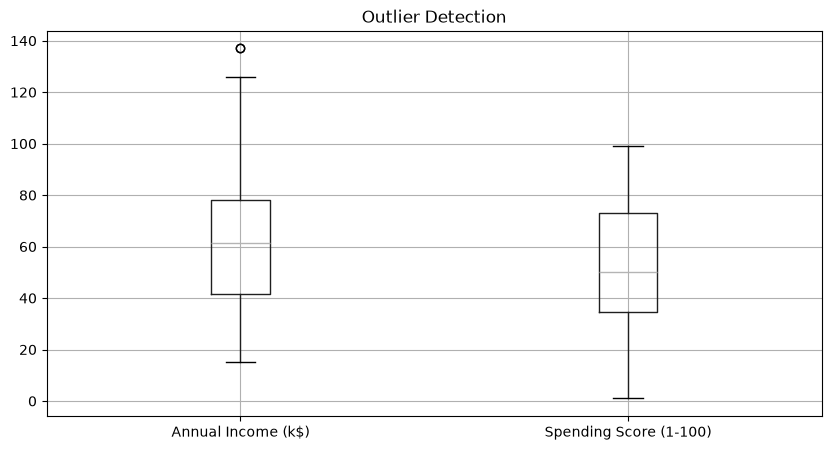

In [93]:
plt.figure(figsize=(10, 5))
df[['Annual Income (k$)', 'Spending Score (1-100)']].boxplot()
plt.title("Outlier Detection")
plt.show()

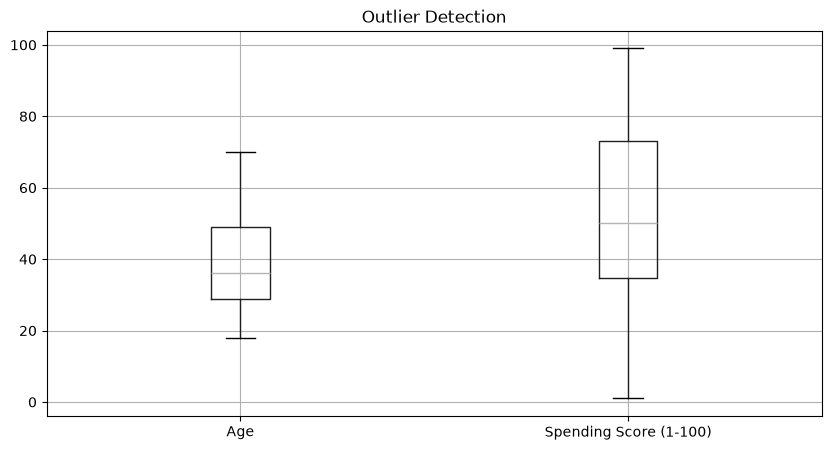

In [94]:
plt.figure(figsize=(10, 5))
df[['Age', 'Spending Score (1-100)']].boxplot()
plt.title("Outlier Detection")
plt.show()

In [95]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [118]:
k_means = KMeans()
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', k_means)
])

# Custom silhouette scorer
def silhouette_scorer(estimator, X, y=None):
    clusters = estimator.predict(X)
    return silhouette_score(X, clusters)

# Parameters to test
param_grid = {
    "model__n_clusters": np.arange(2, 7),
    "model__n_init": np.arange(5, 10),
    "model__random_state": [42]
}

# Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=silhouette_scorer
)

# Train
grid.fit(X)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 943, in _score
    scores = scorer(estimator, X_test, **score_params)
  File "/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_14418/1401224357.py", line 11, in silhouette_scorer
    return silhouette_score(X, clusters)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/cluster/_unsupervised.py", line 146, in silhouette_score
    return float(n

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...', KMeans())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_clusters': array([2, 3, 4, 5, 6]), 'model__n_init': array([5, 6, 7, 8, 9]), 'model__random_state': [42]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function sil...t 0x11fab3b60>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold 

In [119]:
grid.best_params_

{'model__n_clusters': np.int64(2),
 'model__n_init': np.int64(5),
 'model__random_state': 42}

In [ ]:
grid.best_estimator_.

{'scaler': StandardScaler(),
 'model': KMeans(n_clusters=np.int64(2), n_init=np.int64(5), random_state=42)}